In [ ]:
from skimage import io as io
import matplotlib.pyplot as plt

In [ ]:
def plot(x):
    fig, ax = plt.subplots()
    im = ax.imshow(x, cmap = 'gray')
    ax.axis('off')
    fig.set_size_inches(8, 8)
    plt.show()

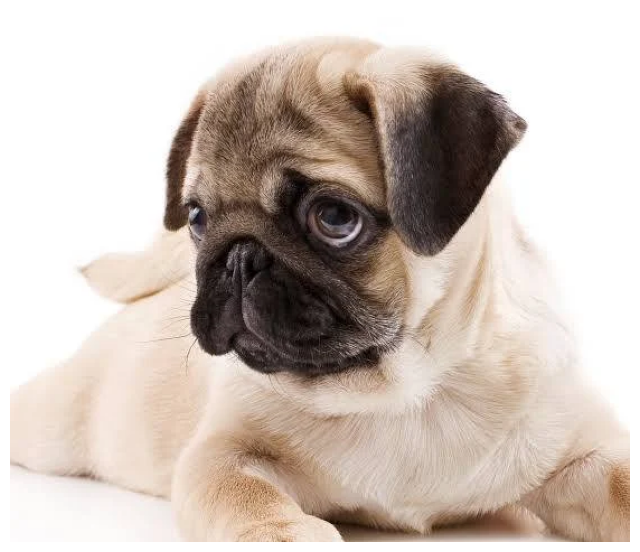

In [ ]:
image = io.imread("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS1zTygfOH8uRpwJhrnBqkaBBm8yPBzBSmO_yjrrxjThazouWvHFhSEAHQaLkNl9gXjsPFdyEgAyH4VKNYmVUiK57hfJmBXUiXzep7dZdVHNQ&s=10")
plot(image)

# Convolution Demo

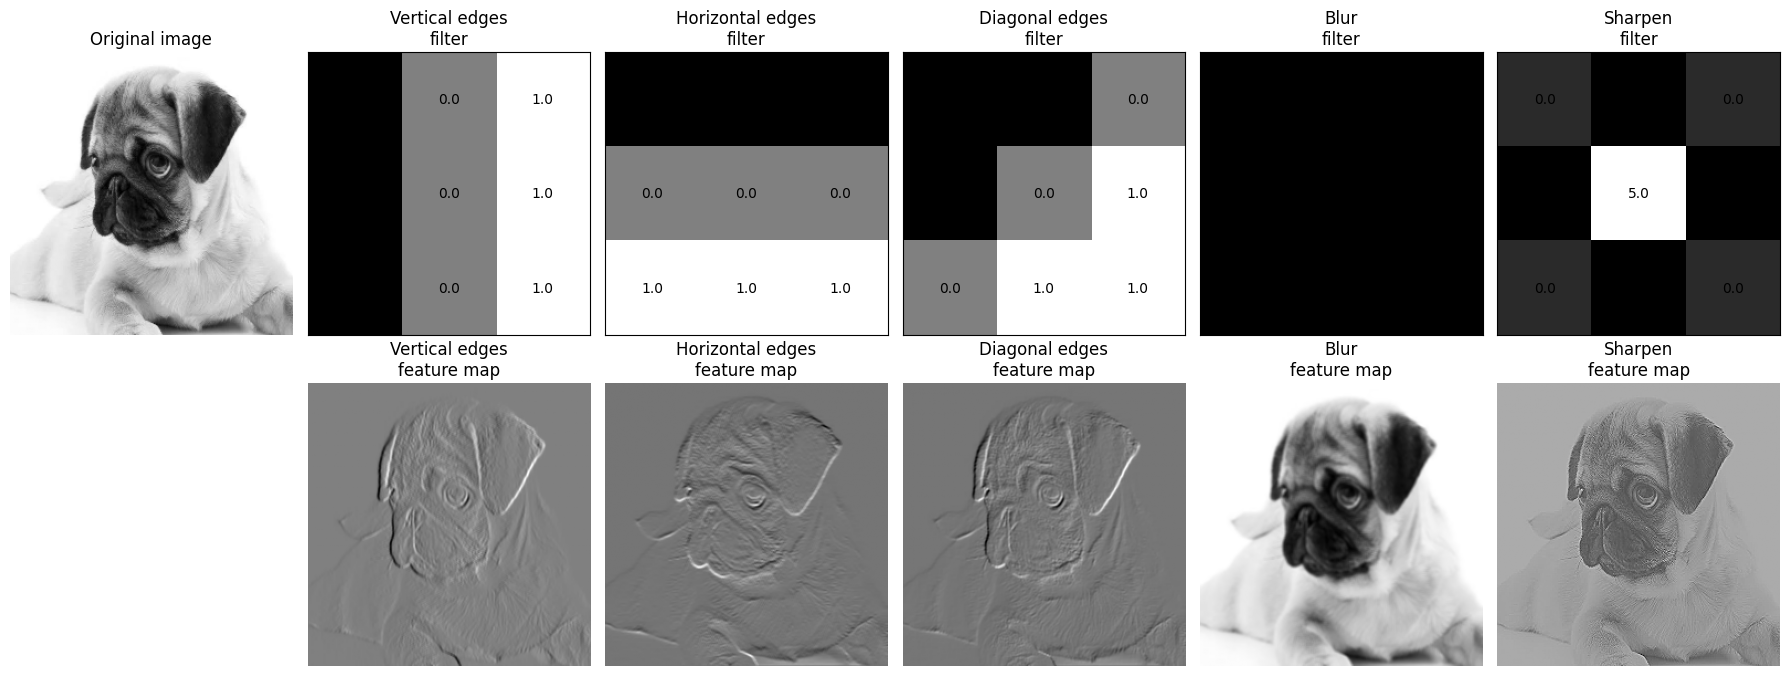

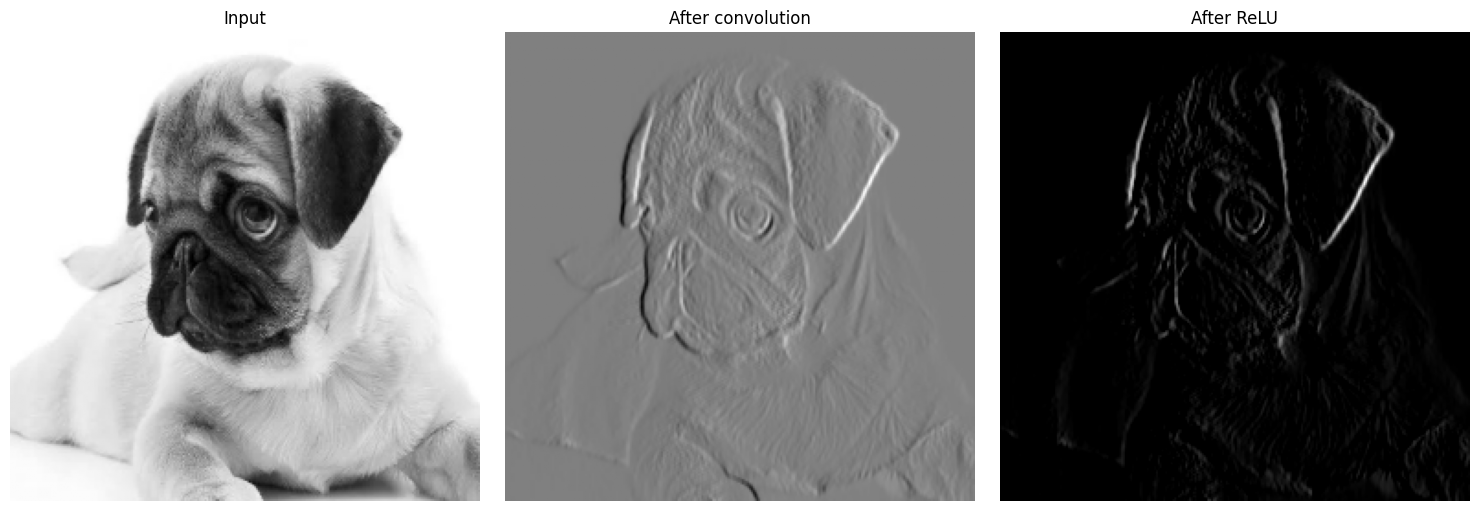

3x3 IMAGE PATCH:
[[0.4  0.34 0.3 ]
 [0.29 0.4  0.37]
 [0.41 0.42 0.36]]

FILTER:
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]

PATCH × FILTER:
[[-0.4   0.    0.3 ]
 [-0.29  0.    0.37]
 [-0.41  0.    0.36]]

SUM:
-0.0721


In [5]:
from skimage import io, color, transform
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import correlate2d


# --------------------------------------------------
# 1. Load an image
# --------------------------------------------------

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS1zTygfOH8uRpwJhrnBqkaBBm8yPBzBSmO_yjrrxjThazouWvHFhSEAHQaLkNl9gXjsPFdyEgAyH4VKNYmVUiK57hfJmBXUiXzep7dZdVHNQ&s=10"

image = io.imread(url)

# Convert RGB -> grayscale
if image.ndim == 3:
    image = color.rgb2gray(image)

# Make it smaller so the filters are easier to inspect
image = transform.resize(image, (256, 256))


# --------------------------------------------------
# 2. Define some CNN-style filters
# --------------------------------------------------

vertical_edge = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

horizontal_edge = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

blur = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) / 9

sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

diagonal_edge = np.array([
    [-1, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  1]
])


filters = {
    "Vertical edges": vertical_edge,
    "Horizontal edges": horizontal_edge,
    "Diagonal edges": diagonal_edge,
    "Blur": blur,
    "Sharpen": sharpen
}


# --------------------------------------------------
# 3. Apply each filter
#
# CNN libraries technically use cross-correlation,
# so correlate2d is a particularly good analogy.
# --------------------------------------------------

feature_maps = {}

for name, kernel in filters.items():
    feature_maps[name] = correlate2d(
        image,
        kernel,
        mode="same",
        boundary="symm"
    )


# --------------------------------------------------
# 4. Plot the filters and resulting feature maps
# --------------------------------------------------

fig, axes = plt.subplots(2, len(filters) + 1, figsize=(18, 7))

# Original image
axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original image")
axes[0, 0].axis("off")

axes[1, 0].axis("off")

for i, (name, kernel) in enumerate(filters.items(), start=1):

    # Show kernel
    axes[0, i].imshow(kernel, cmap="gray")
    axes[0, i].set_title(name + "\nfilter")

    # Write numbers into kernel
    for row in range(kernel.shape[0]):
        for col in range(kernel.shape[1]):
            axes[0, i].text(
                col,
                row,
                f"{kernel[row, col]:.1f}",
                ha="center",
                va="center"
            )

    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

    # Show feature map
    axes[1, i].imshow(feature_maps[name], cmap="gray")
    axes[1, i].set_title(name + "\nfeature map")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 5. Demonstrate ReLU
# --------------------------------------------------

feature = feature_maps["Vertical edges"]

relu_feature = np.maximum(0, feature)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(feature, cmap="gray")
axes[1].set_title("After convolution")
axes[1].axis("off")

axes[2].imshow(relu_feature, cmap="gray")
axes[2].set_title("After ReLU")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# 6. Inspect ONE convolution calculation
# --------------------------------------------------

row = 100
col = 100

patch = image[row-1:row+2, col-1:col+2]

kernel = vertical_edge

elementwise_product = patch * kernel

activation = np.sum(elementwise_product)

print("3x3 IMAGE PATCH:")
print(np.round(patch, 2))

print("\nFILTER:")
print(kernel)

print("\nPATCH × FILTER:")
print(np.round(elementwise_product, 2))

print("\nSUM:")
print(round(activation, 4))

# Convolution as Feature Map

In [6]:
import numpy as np
from skimage import io as io
import matplotlib.pyplot as plt
from scipy import signal
import torch.nn.functional as F
from torch.nn.functional import *
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import time
from matplotlib import animation, rc
from IPython.display import HTML
rc('animation', html='html5')

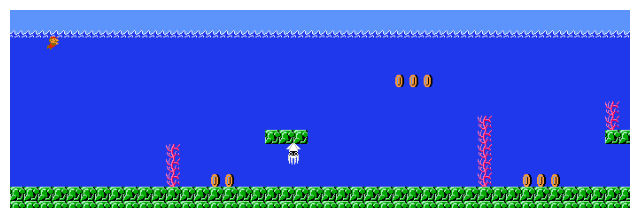

In [8]:
image = io.imread("http://ian-albert.com/games/super_mario_bros_maps/mario-2-2.gif")
image = image[0,:,0:700,:]
plot(image)

In [9]:
coin = image[185:200,224:239,:]

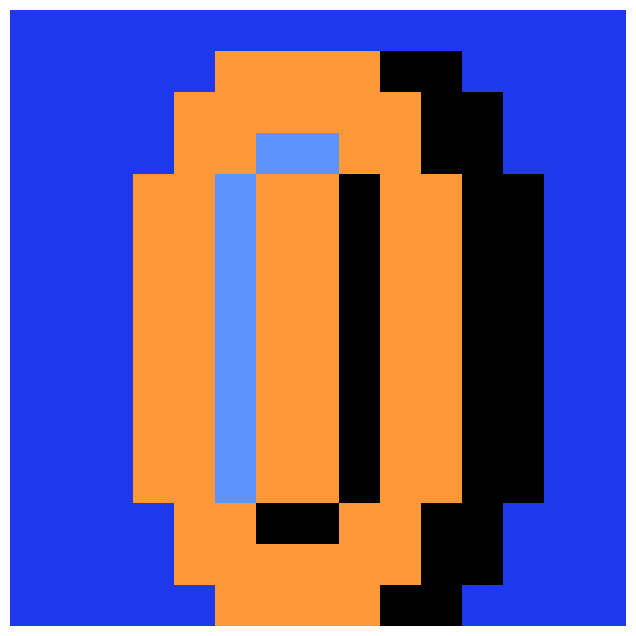

In [10]:
plot(coin)

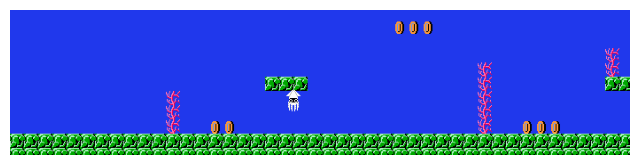

In [11]:
image = image[60:,0:700,:]
plot(image)

In [12]:
def scale1(x):
    return (x-np.min(x))/(np.max(x)-np.min(x))

In [13]:
image=np.mean(image,axis=2)
coin=np.mean(coin,axis=2)

image=scale1(image)
coin=scale1(coin)

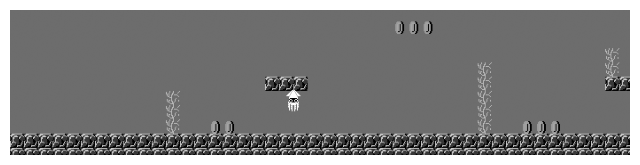

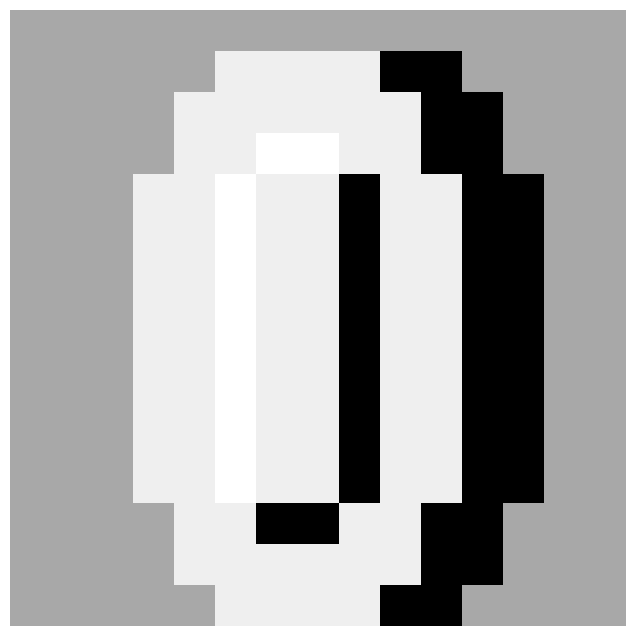

In [14]:
plot(image)
plot(coin)

In [15]:
coin.shape

(15, 15)

In [16]:
image = image - np.mean(image)
coin = coin - np.mean(coin)

In [17]:
image.shape,coin.shape

((164, 700), (15, 15))

In [18]:
z = signal.convolve2d(image, np.rot90(coin, 2))

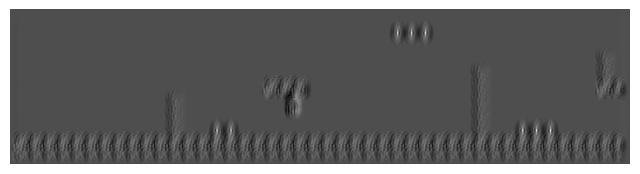

In [19]:
plot(z)

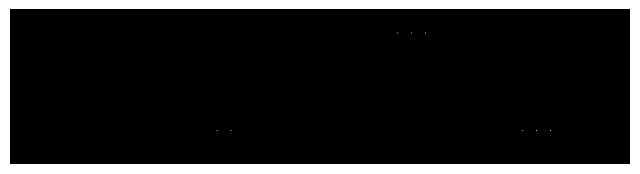

In [20]:
plot(z==np.max(z))

In [21]:
[y,x] = np.where(z == np.amax(z))

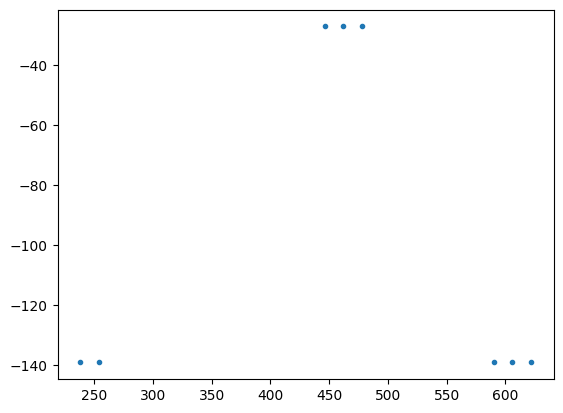

In [22]:
plt.plot(x,-y,'.')

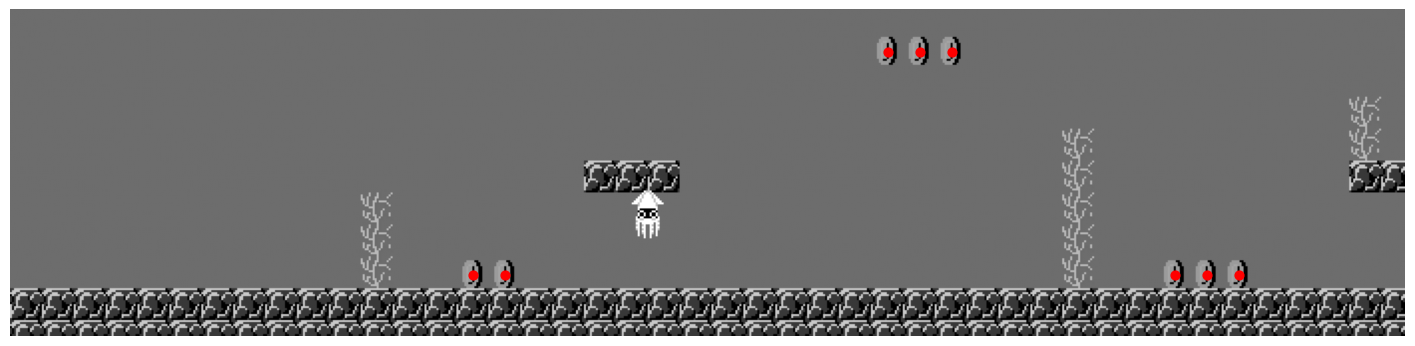

In [23]:
fig, ax = plt.subplots()
im = ax.imshow(image, cmap = 'gray')
ax.axis('off')
ax.scatter(x-6, y-6, c='red', s=40)
fig.set_size_inches(18, 10)